# SVM
- Liad Mandil, 315096073
- Maxim Prokopchuk, 337875397

## Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from sklearn.model_selection import train_test_split , cross_val_score, StratifiedKFold
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, ConfusionMatrixDisplay, confusion_matrix
from sklearn.model_selection import cross_val_score
import seaborn as sns
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
from sklearn.metrics import roc_curve, auc


---------------------

## Helpfull Code

---------------------------------

## Load Data

In [2]:
spaceship_data = pd.read_csv('final_data.csv')

## split to x and y

In [3]:
y = spaceship_data["Transported"].astype(int)
x = spaceship_data.drop(columns=["Transported"])

## Train-Test Split

In [4]:
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42
)

In [5]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

## בדיקת ערכי ההייפר פרמטרים

In [6]:
results = []
best_score = 0
best_params_svm = None

In [7]:
for C in [0.1, 1, 10, 100, 1000]:
    for degree in [1, 2, 3, 4, 5]:

        svm_pipe = Pipeline([
            ("scaler", StandardScaler()),
            ("svm", SVC(
                kernel="poly",
                C=C,
                degree=degree,
                random_state=42
            ))
        ])

        fold_scores = cross_val_score(
            svm_pipe,
            x_train,
            y_train,
            cv=cv,
            scoring="accuracy",
            n_jobs=-1
        )

        mean_score = fold_scores.mean()

        print(f"\nSVM POLY | C={C}, degree={degree}")
        print("Fold accuracies (%):", np.round(100 * fold_scores, 2))
        print(f"Mean CV accuracy: {100 * mean_score:.2f}%")

        results.append({
            "C": C,
            "degree": degree,
            "cv_mean": mean_score,
            "cv_std": fold_scores.std()
        })

        if mean_score > best_score:
            best_score = mean_score
            best_params_svm = {
                "C": C,
                "degree": degree
            }



SVM POLY | C=0.1, degree=1
Fold accuracies (%): [75.4  75.99 77.87 75.24 76.84]
Mean CV accuracy: 76.27%

SVM POLY | C=0.1, degree=2
Fold accuracies (%): [73.21 73.14 74.36 73.05 74.07]
Mean CV accuracy: 73.57%

SVM POLY | C=0.1, degree=3
Fold accuracies (%): [75.04 75.91 76.84 75.53 75.68]
Mean CV accuracy: 75.80%

SVM POLY | C=0.1, degree=4
Fold accuracies (%): [71.75 72.77 73.7  73.41 72.9 ]
Mean CV accuracy: 72.91%

SVM POLY | C=0.1, degree=5
Fold accuracies (%): [69.78 70.88 72.61 71.88 71.95]
Mean CV accuracy: 71.42%

SVM POLY | C=1, degree=1
Fold accuracies (%): [76.57 77.45 80.42 76.77 77.65]
Mean CV accuracy: 77.77%

SVM POLY | C=1, degree=2
Fold accuracies (%): [76.2  76.28 79.55 76.63 76.63]
Mean CV accuracy: 77.06%

SVM POLY | C=1, degree=3
Fold accuracies (%): [77.01 77.01 78.09 77.28 78.09]
Mean CV accuracy: 77.49%

SVM POLY | C=1, degree=4
Fold accuracies (%): [76.42 75.77 77.72 76.7  77.21]
Mean CV accuracy: 76.76%

SVM POLY | C=1, degree=5
Fold accuracies (%): [75.11 

#### הצגת הטובים ביותר ותוצאותיהם

In [8]:
print("\nBest SVM params:", best_params_svm)
print(f"Best CV accuracy: {100 * best_score:.2f}%")

results_df = pd.DataFrame(results).sort_values("cv_mean", ascending=False)

display(results_df.head(10).round(4))


Best SVM params: {'C': 1000, 'degree': 2}
Best CV accuracy: 79.23%


,C,degree,cv_mean,cv_std
21,1000.0,2,0.7923,0.0052
16,100.0,2,0.7910,0.0082
12,10.0,3,0.7904,0.0098
20,1000.0,1,0.7901,0.0115
15,100.0,1,0.7900,0.0116
10,10.0,1,0.7895,0.0130
17,100.0,3,0.7830,0.0046
11,10.0,2,0.7819,0.0095
5,1.0,1,0.7777,0.0139
7,1.0,3,0.7749,0.0049


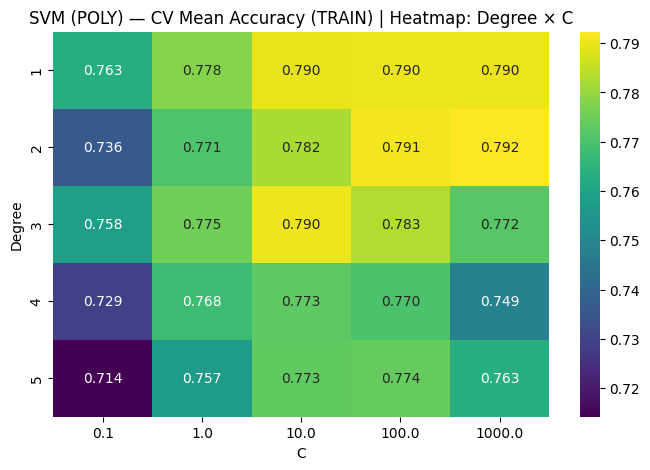

In [9]:
heatmap_data = results_df.pivot(index="degree", columns="C", values="cv_mean")

plt.figure(figsize=(8,5))
sns.heatmap(heatmap_data, annot=True, fmt=".3f", cmap="viridis")
plt.title("SVM (POLY) — CV Mean Accuracy (TRAIN) | Heatmap: Degree × C")
plt.xlabel("C")
plt.ylabel("Degree")
plt.show()

#### Best SVM

In [10]:
best_SVM = Pipeline([
    ("scaler", StandardScaler()),
    ("svm", SVC(
        kernel="poly",
        C=best_params_svm["C"],
        degree=best_params_svm["degree"],
        random_state=42
    ))
])

best_SVM.fit(x_train, y_train)

Pipeline(steps=[('scaler', StandardScaler()),
                ('svm', SVC(C=1000, degree=2, kernel='poly', random_state=42))])

## Results

In [11]:
y_pred_train = best_SVM.predict(x_train)

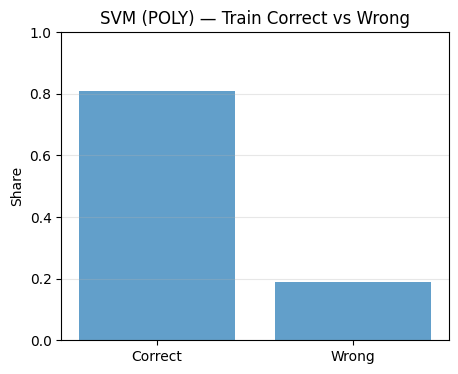

BEST SVM (POLY) — TRAIN SET PERFORMANCE
Accuracy : 80.96%


In [12]:
train_acc = accuracy_score(y_train, y_pred_train)
train_err = 1 - train_acc

plt.figure(figsize=(5,4))
plt.bar(["Correct", "Wrong"], [train_acc, train_err], alpha=0.7)
plt.ylim(0, 1)
plt.ylabel("Share")
plt.title("SVM (POLY) — Train Correct vs Wrong")
plt.grid(axis="y", alpha=0.3)
plt.show()


print("="*40)
print("BEST SVM (POLY) — TRAIN SET PERFORMANCE")
print("="*40)
print(f"Accuracy : {train_acc*100:.2f}%")
print("="*40)

#### confusion_matrix

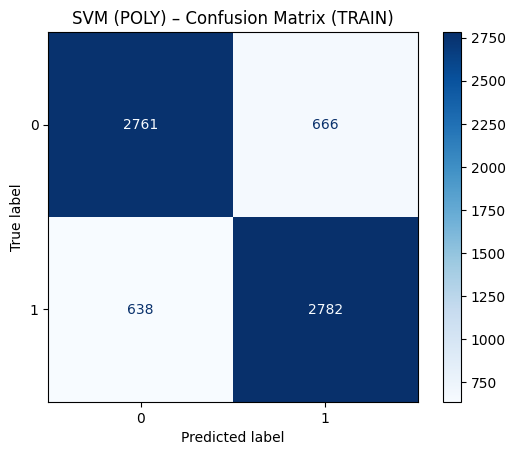

Train Accuracy: 80.96%


In [13]:
cm_train = confusion_matrix(y_train, y_pred_train)

# display
disp = ConfusionMatrixDisplay(confusion_matrix=cm_train)
disp.plot(cmap="Blues")

plt.title("SVM (POLY) – Confusion Matrix (TRAIN)")
plt.show()

print(f"Train Accuracy: {100 * accuracy_score(y_train, y_pred_train):.2f}%")


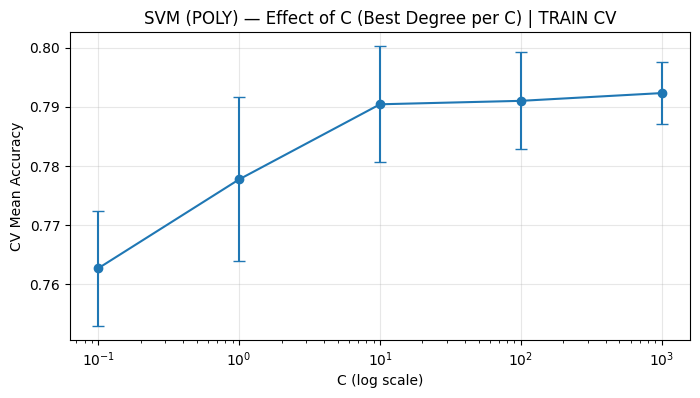

In [14]:
plot_c = (
    results_df
    .sort_values(["C", "cv_mean"], ascending=[True, False])
    .groupby("C", as_index=False)
    .head(1)
    .sort_values("C")
)

plt.figure(figsize=(8,4))
plt.errorbar(plot_c["C"], plot_c["cv_mean"], yerr=plot_c["cv_std"], fmt="o-", capsize=4)
plt.xscale("log")
plt.title("SVM (POLY) — Effect of C (Best Degree per C) | TRAIN CV")
plt.xlabel("C (log scale)")
plt.ylabel("CV Mean Accuracy")
plt.grid(alpha=0.3)
plt.show()

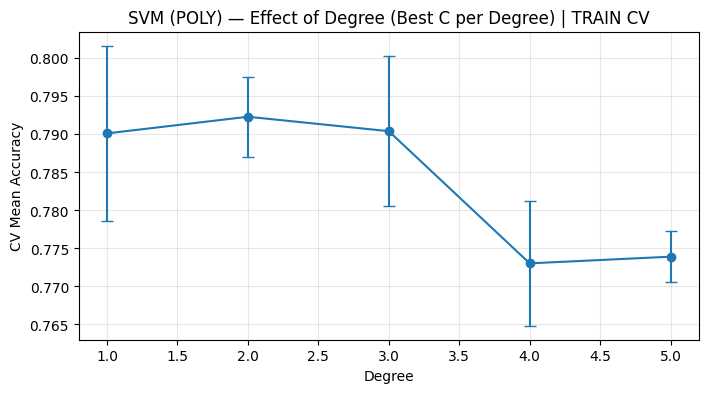

In [15]:
plot_deg = (
    results_df
    .sort_values(["degree", "cv_mean"], ascending=[True, False])
    .groupby("degree", as_index=False)
    .head(1)
    .sort_values("degree")
)

plt.figure(figsize=(8,4))
plt.errorbar(plot_deg["degree"], plot_deg["cv_mean"], yerr=plot_deg["cv_std"], fmt="o-", capsize=4)
plt.title("SVM (POLY) — Effect of Degree (Best C per Degree) | TRAIN CV")
plt.xlabel("Degree")
plt.ylabel("CV Mean Accuracy")
plt.grid(alpha=0.3)
plt.show()

In [16]:
acc = accuracy_score(y_train, y_pred_train)
prec = precision_score(y_train, y_pred_train)
rec = recall_score(y_train, y_pred_train)
f1 = f1_score(y_train, y_pred_train)

metrics_df = pd.DataFrame([{
    "model": "SVM_POLY",
    "accuracy": acc,
    "precision": prec,
    "recall": rec,
    "f1_score": f1
}])

display(metrics_df.round(4))

print("\nClassification Report (TRAIN):")
print(classification_report(y_train, y_pred_train))


,model,accuracy,precision,recall,f1_score
0,SVM_POLY,0.8096,0.8068,0.8135,0.8101



Classification Report (TRAIN):
              precision    recall  f1-score   support

           0       0.81      0.81      0.81      3427
           1       0.81      0.81      0.81      3420

    accuracy                           0.81      6847
   macro avg       0.81      0.81      0.81      6847
weighted avg       0.81      0.81      0.81      6847



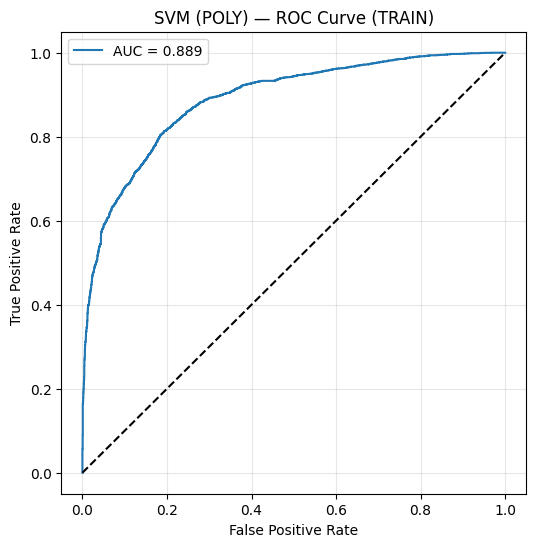

In [17]:
# SVM score for ROC (works without predict_proba)
y_score_train = best_SVM.decision_function(x_train)

fpr, tpr, thresholds = roc_curve(y_train, y_score_train)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0,1], [0,1], "k--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("SVM (POLY) — ROC Curve (TRAIN)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()